### Imports and Setup

In [1]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import h5py
import pyproj as proj
import matplotlib.pyplot as plt

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify

Some Global Setup

In [2]:
# grab device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T
    
# get preprocessor
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

# root path to experimental data examples
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.1).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


Load Experimental Examples To Range

In [3]:
idx_list = [44, 49, 50, 53, 54, 55, 58]

inputs_list = []
sensors_list = []
true_latlon_list = []
for idx in idx_list:
    with h5py.File(os.path.join("/",ccb_data_root,f"gunshots_{idx}.h5"), "r") as f:
        inputs_list.append(f["/data"][:])
        sensors_list.append(f["/sensors"][:].squeeze())
        true_latlon_list.append(f["/location"][:].squeeze())

### Helper Functions

In [4]:
def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def preprocess_individual_examples(inputs, sensors, true_latlon):
    """
    Preprocess individual examples for processing
    
    
    """
    
    assert (isinstance(inputs, list) and isinstance(sensors, list) and isinstance(true_latlon, list)) or \
           (isinstance(inputs, np.ndarray) and isinstance(sensors, np.ndarray) and isinstance(true_latlon, np.ndarray)), "inputs must be numpy arrays or lists of numpy arrays"
    
    if isinstance(inputs, np.ndarray) and isinstance(sensors, np.ndarray) and isinstance(true_latlon, np.ndarray):
        sensors = [sensors]
        true_latlon = [true_latlon]
    else:
        inputs = np.concatenate(inputs, axis=0)
    
    # preprocess
    inputs = preprocessor(inputs)
    
    ranges_list = []
    for sen, pos in zip(sensors, true_latlon):
        
        # get sensor indices
        sensor_indices = sensor2idx(sen)

        # get position and sensor ranges
        xt, yt = pargs(pos[1], pos[0])
        yt = -yt
        location_m = np.asarray([[yt, xt]])
        ranges = np.sqrt(((TOSSIT_locations - location_m) ** 2).sum(axis=1))
        ranges_list.extend(ranges)

    return inputs, np.asarray(ranges_list)

def plot_range_regression(r_t, r_p):

    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 7000)

    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=2, label="in-distribution data")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.xlim(0, r_mm[-1] / 1000)
    plt.ylim(0, r_mm[-1] / 1000)

### Predict Ranges

In [10]:
# preprocess inputs
inputs, ranges = preprocess_individual_examples(inputs_list, sensors_list, true_latlon_list)

with torch.set_grad_enabled(False):
    inputs = inputs.to(device)
    outputs = model(inputs).to('cpu')
    
# get indices of detections and where 
# true ranges fall in synthetic range distribution
detections_idx = np.where((F.softmax(outputs[:,1:], dim=1)[:,1] >= 0.5) & (ranges >= config['scaling']['min_r']) & (ranges <= config['scaling']['max_r']))[0]
rp_detec = (outputs[detections_idx,0] * config['scaling']['max_r']).numpy()
rt_detec = ranges[detections_idx]
detected_num = len(detections_idx)
detect_possible = ((ranges >= config['scaling']['min_r']) & (ranges <= config['scaling']['max_r'])).sum()

detections_idx_ood = np.where((F.softmax(outputs[:,1:], dim=1)[:,1] >= 0.5) & (ranges < config['scaling']['min_r']) | (ranges > config['scaling']['max_r']))[0]
rp_detec_ood = (outputs[detections_idx_ood,0] * config['scaling']['max_r']).numpy()
rt_detec_ood = ranges[detections_idx_ood]
detected_num_ood = len(detections_idx_ood)
detect_possible_ood = ((ranges < config['scaling']['min_r']) | (ranges > config['scaling']['max_r'])).sum()

detections_idx_all = np.where((F.softmax(outputs[:,1:], dim=1)[:,1] >= 0.5))[0]
rp_detec_all = (outputs[detections_idx_all,0] * config['scaling']['max_r']).numpy()
rt_detec_all = ranges[detections_idx_all]
detected_num_all = len(detections_idx_all)
detect_possible_all = len(ranges)

statistics (in-distribution)
----------------------------
RMSE: 656.765 m
MAE: 502.881 m
MAPE: 6.63 %
Detections: 86/86 (100.0 %)

statistics (out-of-distribution)
--------------------------------
RMSE: 2695.305 m
MAE: 2186.522 m
MAPE: 74.182 %
Detections: 29/33 (87.88 %)

statistics (all)
----------------
RMSE: 1467.831 m
MAE: 927.451 m
MAPE: 23.665 %
Detections: 115/119 (96.64 %)



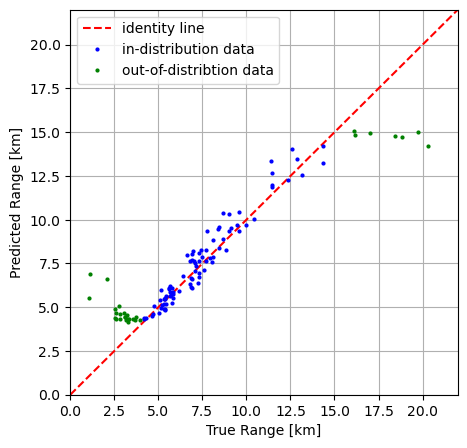

In [19]:
fig = plt.figure(figsize=(5,5))
plot_range_regression(rt_detec, rp_detec)
plt.plot(rt_detec_ood / 1000, rp_detec_ood / 1000, 'go', markersize=2, label="out-of-distribtion data")
plt.legend()

rmse = np.sqrt(((rp_detec - rt_detec) ** 2).mean())
mae = np.abs(rp_detec - rt_detec).mean()
mape = np.abs((rt_detec - rp_detec) / rt_detec).mean()

print("statistics (in-distribution)")
print("----------------------------")
print(f'RMSE: {np.around(rmse, 3)} m')
print(f'MAE: {np.around(mae, 3)} m')
print(f'MAPE: {np.around(mape * 100, 3)} %')
print(f'Detections: {detected_num}/{detect_possible} ({np.around(100 *detected_num / detect_possible, 3)} %)\n')

rmse_ood = np.sqrt(((rp_detec_ood - rt_detec_ood) ** 2).mean())
mae_ood = np.abs(rp_detec_ood - rt_detec_ood).mean()
mape_ood = np.abs((rt_detec_ood - rp_detec_ood) / rt_detec_ood).mean()

print("statistics (out-of-distribution)")
print("--------------------------------")
print(f'RMSE: {np.around(rmse_ood, 3)} m')
print(f'MAE: {np.around(mae_ood, 3)} m')
print(f'MAPE: {np.around(mape_ood * 100, 3)} %')
print(f'Detections: {detected_num_ood}/{detect_possible_ood} ({np.around(100 *detected_num_ood / detect_possible_ood, 2)} %)\n')

rmse_all = np.sqrt(((rp_detec_all - rt_detec_all) ** 2).mean())
mae_all = np.abs(rp_detec_all - rt_detec_all).mean()
mape_all = np.abs((rt_detec_all - rp_detec_all) / rt_detec_all).mean()

print("statistics (all)")
print("----------------")
print(f'RMSE: {np.around(rmse_all, 3)} m')
print(f'MAE: {np.around(mae_all, 3)} m')
print(f'MAPE: {np.around(mape_all * 100, 3)} %')
print(f'Detections: {detected_num_all}/{detect_possible_all} ({np.around(100 *detected_num_all / detect_possible_all, 2)} %)\n')